     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.5 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda | torch 2.11.0+cu130
GPU: Tesla T4
npz keys: ['X', 'M', 'K', 'id', 'split', 'dice_range', 'malignancy', 'dice_mean']

X (2394, 256, 256, 3) uint8 | M (2394, 5, 256, 256) uint8 | K (2394,) int64
K values: {np.int64(2): np.int64(2130), np.int64(3): np.int64(209), np.int64(4): np.int64(51), np.int64(5): np.int64(4)}
All padding slots are zero: True

Split counts: {np.str_('test'): np.int64(479), np.str_('train'): np.int64(1675), np.str_('val'): np.int64(240)}
train/val/test = 1675 / 240 / 479
dice_range counts: {np.str_('high'): np.int64(1582), np.str_('low')

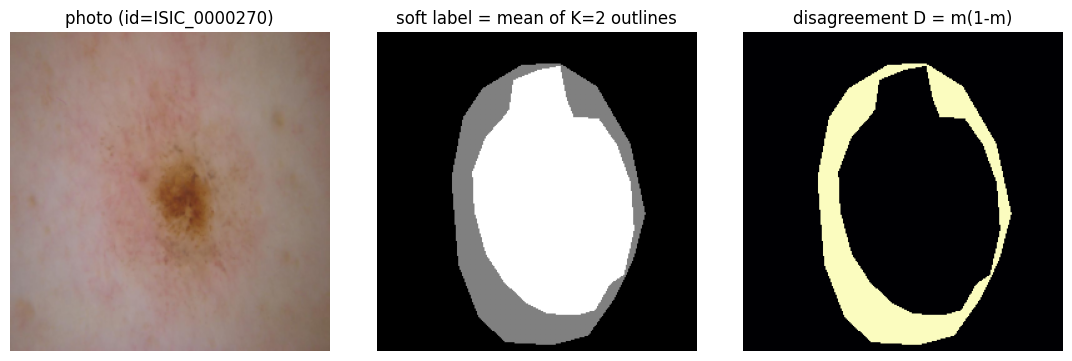

Cell 1 done.


In [ ]:
# ============================================================
# CELL 1 - Installs, imports, load data, sanity checks
# ============================================================
!pip -q install segmentation-models-pytorch==0.3.3   # pinned for the stable encoder_weights API

import os, time, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import segmentation_models_pytorch as smp
from scipy import ndimage, stats
from sklearn.metrics import roc_auc_score

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True   # speed-up for fixed 256x256 inputs

# ---------- paths ----------
DRIVE_DIR = "/content/drive/MyDrive/IMA_project"
DATA_PATH = os.path.join(DRIVE_DIR, "ima_256.npz")
CKPT_LAST = os.path.join(DRIVE_DIR, "ckpt_last.pt")
CKPT_BEST = os.path.join(DRIVE_DIR, "ckpt_best.pt")

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_DIR, exist_ok=True)

# ---------- device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| torch", torch.__version__)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ---------- load data (fits easily in Colab RAM, ~1.3 GB as uint8) ----------
data = np.load(DATA_PATH, allow_pickle=True)
print("npz keys:", list(data.keys()))

X          = data["X"]                  # uint8 (N,256,256,3) RGB dermoscopy photos
M          = data["M"]                  # uint8 (N,5,256,256) annotator outlines 0/1, zero-padded
K          = data["K"]                  # int (N,) number of REAL outlines per image
ids        = data["id"]
split      = data["split"]
dice_range = data["dice_range"]         # 'low'/'medium'/'high' agreement between annotators
malignancy = data["malignancy"]         # string label
dice_mean  = data["dice_mean"].astype(np.float32)   # mean pairwise human-human Dice

N = len(X)
print(f"\nX {X.shape} {X.dtype} | M {M.shape} {M.dtype} | K {K.shape} {K.dtype}")
print("K values:", dict(zip(*np.unique(K, return_counts=True))))

# ---------- sanity checks ----------
assert X.shape == (N, 256, 256, 3) and M.shape == (N, 5, 256, 256)
assert set(np.unique(M)) <= {0, 1}, "M must be binary"
assert int(K.min()) >= 2 and int(K.max()) <= 5, "K must be in 2..5"

# padding slots (indices >= K[i]) must be all zero - vectorized check
real_slot = np.arange(5)[None, :] < np.asarray(K)[:, None]      # (N,5) True where slot is real
pad_all_zero = (not M[~real_slot].any())
print("All padding slots are zero:", pad_all_zero)
assert pad_all_zero, "Non-zero padding found - slots >= K[i] must never be used!"

print("\nSplit counts:", dict(zip(*np.unique(split, return_counts=True))))
train_idx = np.where(split == "train")[0]
val_idx   = np.where(split == "val")[0]
test_idx  = np.where(split == "test")[0]
# if your file intentionally differs, relax this assert
assert (len(train_idx), len(val_idx), len(test_idx)) == (1675, 240, 479), "Unexpected split sizes!"
print("train/val/test =", len(train_idx), "/", len(val_idx), "/", len(test_idx))

print("dice_range counts:", dict(zip(*np.unique(dice_range, return_counts=True))))
print("malignancy counts:", dict(zip(*np.unique(malignancy, return_counts=True))))
print(f"dice_mean: min {dice_mean.min():.3f} | mean {dice_mean.mean():.3f} | max {dice_mean.max():.3f}")

# ---------- visual check: one TRAIN image, its soft label, its disagreement map ----------
i0 = int(train_idx[0])
m0 = M[i0, :int(K[i0])].astype(np.float32).mean(axis=0)   # mean of the K REAL outlines
fig, ax = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)
ax[0].imshow(X[i0]);                            ax[0].set_title(f"photo (id={ids[i0]})")
ax[1].imshow(m0, cmap="gray", vmin=0, vmax=1);  ax[1].set_title(f"soft label = mean of K={int(K[i0])} outlines")
ax[2].imshow(m0 * (1 - m0), cmap="magma", vmin=0, vmax=0.25); ax[2].set_title("disagreement D = m(1-m)")
for a in ax: a.axis("off")
plt.show()
print("Cell 1 done.")

In [ ]:
# ============================================================
# CELL 2 - Dataset (soft labels + augmentation) and U-Net model
# ============================================================
BATCH_SIZE    = 16
DROPOUT_P     = 0.25    # Dropout2d prob, in the 0.2-0.3 range (also used by MC-Dropout later)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ---- soft label: mean of the K REAL outlines (padding slots never touched) ----
def soft_label(i):
    return M[i, :int(K[i])].astype(np.float32).mean(axis=0)      # (256,256), values in [0,1]

# ---- ImageNet normalization ----
def normalize_image(x_u8):
    x = x_u8.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD                       # HWC
    return torch.from_numpy(x.transpose(2, 0, 1).copy())         # CHW float32

# ---- train-time augmentation: ONE random transform, identical for photo + target ----
# (the target is the mean of the outlines, so transforming the mean is equivalent
#  to transforming every outline the same way - flips/rotations are per-pixel maps)
def augment_pair(x_u8, m):
    if random.random() < 0.5: x_u8, m = x_u8[:, ::-1], m[:, ::-1]      # horizontal flip
    if random.random() < 0.5: x_u8, m = x_u8[::-1],     m[::-1]        # vertical flip
    k = random.randint(0, 3)
    if k:                     x_u8, m = np.rot90(x_u8, k), np.rot90(m, k)  # 90deg rotations
    return np.ascontiguousarray(x_u8), np.ascontiguousarray(m)

class LesionDataset(Dataset):
    """Yields (normalized image CHW, soft label (1,256,256), original index)."""
    def __init__(self, indices, train):
        self.indices = np.asarray(indices)
        self.train = train
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, n):
        i = int(self.indices[n])
        x_u8, m = X[i], soft_label(i)
        if self.train:
            x_u8, m = augment_pair(x_u8, m)
        img = normalize_image(x_u8)
        msk = torch.from_numpy(m.copy()).unsqueeze(0)     # (1,256,256)
        return img, msk, i

def seed_worker(worker_id):
    # keep python/numpy RNG inside DataLoader workers reproducible too
    s = torch.initial_seed() % 2**32
    random.seed(s); np.random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)
train_dl = DataLoader(LesionDataset(train_idx, train=True),  batch_size=BATCH_SIZE,
                      shuffle=True, num_workers=2, pin_memory=True,
                      generator=g, worker_init_fn=seed_worker)
val_dl   = DataLoader(LesionDataset(val_idx, train=False), batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=2, pin_memory=True)
print("batches per epoch: train", len(train_dl), "| val", len(val_dl))

# ---- loss: soft BCE-with-logits + soft Dice (targets may be any value in [0,1]) ----
def bce_loss(logits, target):
    return F.binary_cross_entropy_with_logits(logits, target)

def soft_dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * target).sum(dim=(1, 2, 3))
    denom = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    # eps=1.0 -> empty-vs-empty counts as perfect agreement (loss 0)
    return 1.0 - ((2 * inter + eps) / (denom + eps)).mean()

def combined_loss(logits, target):
    return bce_loss(logits, target) + soft_dice_loss(logits, target)

# ---- model: ImageNet-pretrained ResNet34 U-Net + Dropout2d before the final conv ----
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1, activation=None)   # outputs logits
# inject Dropout2d right before the segmentation head -> makes MC-Dropout possible
model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT_P),
                                        model.segmentation_head)
model = model.to(device)
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print("segmentation head:", model.segmentation_head)

with torch.no_grad():
    dummy = model(torch.zeros(2, 3, 256, 256, device=device))
print("dummy forward:", tuple(dummy.shape), "(expect (2, 1, 256, 256))")
print("Cell 2 done.")

batches per epoch: train 105 | val 15
Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 283MB/s]


params: 24.4M
segmentation head: Sequential(
  (0): Dropout2d(p=0.25, inplace=False)
  (1): SegmentationHead(
    (0): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Identity()
    (2): Activation(
      (activation): Identity()
    )
  )
)
dummy forward: (2, 1, 256, 256) (expect (2, 1, 256, 256))
Cell 2 done.


In [ ]:
# ============================================================
# CELL 3 - Training (Adam, batch 16, AMP, checkpoints to Drive, resume)
# ============================================================
EPOCHS = 30
LR     = 1e-4     # standard for fine-tuning a pretrained encoder (a setting you can tune on val)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
use_amp = device.type == "cuda"
if hasattr(torch.amp, "GradScaler"):                     # torch >= 2.3
    scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)
else:                                                    # older torch
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

history = {"train_loss": [], "val_loss": [], "val_dice": []}
start_epoch, best_val = 1, float("inf")

# ---- resume after a disconnect (ckpt_last.pt = state at end of last completed epoch) ----
if os.path.exists(CKPT_LAST):
    try:
        ck = torch.load(CKPT_LAST, map_location=device)
        model.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        if "scaler" in ck and use_amp:
            scaler.load_state_dict(ck["scaler"])
        start_epoch = ck["epoch"] + 1
        best_val    = ck["best_val"]
        history     = ck["history"]
        print(f"Resumed: last completed epoch {ck['epoch']} | best val loss so far {best_val:.4f}")
    except Exception as e:
        print(f"WARNING: could not read ckpt_last.pt ({e}) - starting fresh.")
else:
    print("No checkpoint found - starting fresh.")

def save_ckpt(payload, path):
    tmp = "/content/_tmp_ckpt.pt"     # write locally first, then copy to Drive (safer)
    torch.save(payload, tmp)
    shutil.copy2(tmp, path)

def run_epoch(loader, training, desc):
    model.train(training)
    tot, nb = 0.0, 0
    with torch.set_grad_enabled(training):
        for img, msk, _ in tqdm(loader, desc=desc, leave=False):
            img = img.to(device, non_blocking=True)
            msk = msk.to(device, non_blocking=True)
            with torch.autocast("cuda", enabled=use_amp):
                loss = combined_loss(model(img), msk)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            tot += loss.item(); nb += 1
    return tot / max(nb, 1)

@torch.no_grad()
def val_dice(loader):
    """Thresholded prediction vs binarized soft label - progress indicator ONLY.
    Epoch selection uses the val loss."""
    model.eval()
    ds = []
    for img, msk, _ in loader:
        pred = torch.sigmoid(model(img.to(device))) > 0.5
        tgt  = msk.to(device) > 0.5
        inter = (pred & tgt).sum(dim=(1, 2, 3)).float()
        denom = (pred.sum(dim=(1, 2, 3)) + tgt.sum(dim=(1, 2, 3))).float()
        d = torch.where(denom > 0, 2 * inter / denom.clamp(min=1e-6), torch.ones_like(denom))
        ds.append(d.cpu())
    return torch.cat(ds).mean().item()

if start_epoch > EPOCHS:
    print("ckpt_last.pt already reached EPOCHS - nothing to train, go to cell 4.")

print(f"Training epochs {start_epoch}..{EPOCHS} | AMP={use_amp} | batch={BATCH_SIZE}")
t0 = time.time()
for epoch in range(start_epoch, EPOCHS + 1):
    tr = run_epoch(train_dl, True,  f"train ep{epoch}")
    va = run_epoch(val_dl,   False, f"val ep{epoch}")
    vd = val_dice(val_dl)
    history["train_loss"].append(tr)
    history["val_loss"].append(va)
    history["val_dice"].append(vd)
    is_best = va < best_val
    best_val = min(best_val, va)
    payload = {"epoch": epoch, "best_val": best_val, "history": history,
               "model": model.state_dict(), "optimizer": optimizer.state_dict(),
               "scaler": scaler.state_dict()}
    save_ckpt(payload, CKPT_LAST)          # every epoch
    if is_best:
        save_ckpt(payload, CKPT_BEST)      # only when val loss improves
    print(f"epoch {epoch:2d}/{EPOCHS} | train {tr:.4f} | val {va:.4f} | val_dice {vd:.4f} "
          f"| best {best_val:.4f}{' *' if is_best else ''} | {time.time()-t0:.0f}s")

# ---- training / validation curves ----
if len(history["val_loss"]) > 0:
    ep = np.arange(1, len(history["val_loss"]) + 1)
    best_ep = int(np.argmin(history["val_loss"])) + 1
    fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    ax[0].plot(ep, history["train_loss"], label="train")
    ax[0].plot(ep, history["val_loss"], label="val")
    ax[0].axvline(best_ep, ls="--", c="gray", label=f"best ep {best_ep}")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("BCE + soft Dice loss"); ax[0].legend()
    ax[1].plot(ep, history["val_dice"], c="tab:green")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("Dice"); ax[1].set_title("val Dice (vs binarized soft label)")
    plt.savefig(os.path.join(DRIVE_DIR, "training_curves.png"), dpi=150)
    plt.show()
    print(f"Best epoch by val loss: {best_ep} (val loss {min(history['val_loss']):.4f})")
    print(f"Checkpoints in {DRIVE_DIR} (ckpt_last.pt, ckpt_best.pt)")

Loaded ckpt_best.pt | epoch 26 | val loss 0.3150
So far the test split has not been touched (only split counts were printed in cell 1).


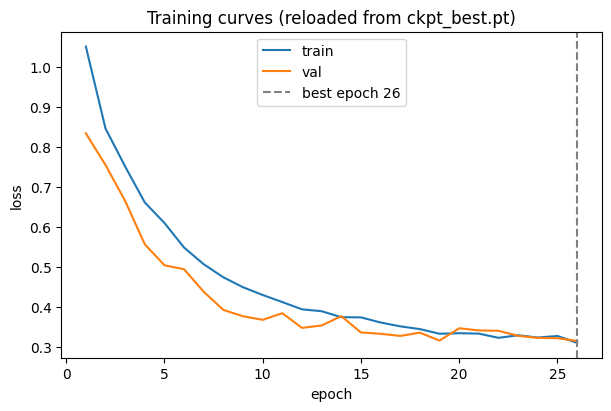

In [ ]:
# ============================================================
# CELL 4 - Load best checkpoint (selected on val loss ONLY)
# ============================================================
# Requires cells 1 and 2 to have run in this session (paths + model must exist).
if not os.path.exists(CKPT_BEST):
    raise RuntimeError("ckpt_best.pt not found - run cell 3 (training) first.")

ck = torch.load(CKPT_BEST, map_location=device)
model.load_state_dict(ck["model"])
model.eval()
print(f"Loaded ckpt_best.pt | epoch {ck['epoch']} | val loss {ck['best_val']:.4f}")
print("So far the test split has not been touched (only split counts were printed in cell 1).")

h = ck["history"]
ep = np.arange(1, len(h["val_loss"]) + 1)
plt.figure(figsize=(6, 4), constrained_layout=True)
plt.plot(ep, h["train_loss"], label="train")
plt.plot(ep, h["val_loss"], label="val")
plt.axvline(ck["epoch"], ls="--", c="gray", label=f"best epoch {ck['epoch']}")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("Training curves (reloaded from ckpt_best.pt)")
plt.savefig(os.path.join(DRIVE_DIR, "training_curves.png"), dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 5 - Uncertainty maps + metrics on the TEST set
# ============================================================
# Requires cells 1, 2, 4. This is the ONLY cell that touches test images.
#
# Per test image:
#   A  p          : deterministic prediction (dropout off, BatchNorm in eval)
#   B  p(1-p)     : data-uncertainty map
#   C  var        : MC-Dropout model-uncertainty map (16 passes, dropout on, BN in eval)
#   D  edge band  : blurred band around the thresholded boundary (dumb baseline)
#   GT D = m(1-m) : true human disagreement (evaluation reference only)
T_MC    = 16     # MC-Dropout forward passes
EDGE_PX = 3      # half-width in px of the baseline edge band (a baseline setting you can tweak)

torch.manual_seed(SEED)   # reproducible dropout-mask sequence for the MC passes

def dice_np(a, b, eps=1e-6):
    """Dice between two boolean masks; both empty -> 1.0 (they agree)."""
    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0
    return float(2.0 * np.logical_and(a, b).sum() / (denom + eps))

def pearson_with_D(map_, D):
    """Per-image Pearson r between a map and D. NaN -> image skipped
    (D constant / all zero, or the map itself is constant)."""
    if map_.std() == 0 or D.std() == 0:
        return np.nan
    return float(np.corrcoef(map_.ravel(), D.ravel())[0, 1])

def auc_disagreement(map_, m):
    """Per-image pixel-level ROC-AUC: does the map rank disagreement pixels
    (0 < m < 1) above agreed pixels? NaN -> image skipped (no disagreement
    pixels, or constant map)."""
    lab = (m > 0) & (m < 1)
    if lab.all() or (~lab).all() or map_.std() == 0:
        return np.nan
    return float(roc_auc_score(lab.ravel(), map_.ravel()))

def edge_band_baseline(pred, half_width=EDGE_PX):
    """Blurred band around the boundary of the binary prediction, normalized to 0-1."""
    st = np.ones((3, 3), dtype=bool)
    grown  = ndimage.binary_dilation(pred, structure=st, iterations=half_width)
    shrunk = ndimage.binary_erosion(pred, structure=st, iterations=half_width)
    band = (grown & ~shrunk).astype(np.float32)
    if band.max() > 0:
        band = ndimage.gaussian_filter(band, sigma=1.5)
        if band.max() > 0:
            band = band / band.max()
    return band.astype(np.float32)

# ---------------- per-image loop over the test set ----------------
res = {k: [] for k in ["idx", "dice_range", "malignancy", "dice_mean",
                       "dice_pred_vs_ann",
                       "pearson_data_unc", "pearson_mc_dropout", "pearson_edge_base",
                       "auc_data_unc", "auc_mc_dropout", "auc_edge_base",
                       "mean_data_unc", "mean_mc_dropout", "mean_edge_base", "mean_gt"]}
keep_maps = {"data_unc": [], "mc_dropout": [], "edge_base": [], "gt": [], "pred": []}

t0 = time.time()
for n, i in enumerate(tqdm(test_idx, desc="test images")):
    i = int(i)
    m = soft_label(i)                               # mean of the K REAL outlines
    D_gt = m * (1.0 - m)                            # ground-truth disagreement map
    x = normalize_image(X[i]).unsqueeze(0)          # (1,3,256,256)

    # A) deterministic prediction (dropout OFF, BN in eval)
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(x.to(device)))[0, 0].cpu().numpy().astype(np.float32)

    # B) data uncertainty
    unc_data = p * (1.0 - p)

    # C) MC-Dropout: ONLY dropout active (BN stays in eval). One batch of T identical
    #    inputs = T independent dropout masks in a single forward pass.
    for mod in model.modules():
        if isinstance(mod, (nn.Dropout, nn.Dropout2d)):
            mod.train()
    with torch.no_grad():
        probs = torch.sigmoid(model(x.repeat(T_MC, 1, 1, 1).to(device)))[:, 0]   # (T,256,256)
        unc_mc = probs.var(dim=0, unbiased=False).cpu().numpy().astype(np.float32)
    model.eval()

    # D) edge-band baseline around the thresholded prediction
    pred = p > 0.5
    unc_edge = edge_band_baseline(pred)

    # Dice vs each REAL annotator outline, averaged per image
    dices = [dice_np(pred, M[i, k] > 0) for k in range(int(K[i]))]
    dice_ann = float(np.mean(dices))

    # per-image metrics
    res["idx"].append(i)
    res["dice_range"].append(str(dice_range[i]))
    res["malignancy"].append(str(malignancy[i]))
    res["dice_mean"].append(float(dice_mean[i]))
    res["dice_pred_vs_ann"].append(dice_ann)
    res["pearson_data_unc"].append(pearson_with_D(unc_data, D_gt))
    res["pearson_mc_dropout"].append(pearson_with_D(unc_mc, D_gt))
    res["pearson_edge_base"].append(pearson_with_D(unc_edge, D_gt))
    res["auc_data_unc"].append(auc_disagreement(unc_data, m))
    res["auc_mc_dropout"].append(auc_disagreement(unc_mc, m))
    res["auc_edge_base"].append(auc_disagreement(unc_edge, m))
    res["mean_data_unc"].append(float(unc_data.mean()))
    res["mean_mc_dropout"].append(float(unc_mc.mean()))
    res["mean_edge_base"].append(float(unc_edge.mean()))
    res["mean_gt"].append(float(D_gt.mean()))

    # keep maps (float16) for the figures in cell 6
    keep_maps["data_unc"].append(unc_data.astype(np.float16))
    keep_maps["mc_dropout"].append(unc_mc.astype(np.float16))
    keep_maps["edge_base"].append(unc_edge.astype(np.float16))
    keep_maps["gt"].append(D_gt.astype(np.float16))
    keep_maps["pred"].append(pred)

R = {k: np.array(v) for k, v in res.items()}
print(f"Done in {time.time()-t0:.0f}s for {len(test_idx)} test images.")

# ---------------- aggregate per group ----------------
def nanmean_safe(a):
    a = np.asarray(a, dtype=np.float64)
    return float(np.nanmean(a)) if np.isfinite(a).any() else np.nan

def spearman_safe(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3 or np.unique(x[ok]).size < 2 or np.unique(y[ok]).size < 2:
        return np.nan
    r = stats.spearmanr(x[ok], y[ok])
    return float(getattr(r, "statistic", getattr(r, "correlation", np.nan)))

groups = [("overall", "all", np.ones(len(test_idx), dtype=bool))]
for v in np.unique(R["dice_range"]):
    groups.append(("dice_range", str(v), R["dice_range"] == v))
for v in np.unique(R["malignancy"]):
    groups.append(("malignancy", str(v), R["malignancy"] == v))

MAPS = ["data_unc", "mc_dropout", "edge_base"]    # maps B, C and the D baseline
rows = []
for gtype, gname, sel in groups:
    row = {"group_type": gtype, "group": gname, "n_images": int(sel.sum())}
    row["dice_pred_vs_ann"] = nanmean_safe(R["dice_pred_vs_ann"][sel])
    row["dice_human_human"] = nanmean_safe(R["dice_mean"][sel])   # reference: dice_mean column
    for tag in MAPS:
        row[f"pearson_{tag}"] = nanmean_safe(R[f"pearson_{tag}"][sel])
        row[f"pearson_{tag}_skipped"] = int(np.isnan(R[f"pearson_{tag}"][sel]).sum())
        row[f"auc_{tag}"] = nanmean_safe(R[f"auc_{tag}"][sel])
        row[f"auc_{tag}_skipped"] = int(np.isnan(R[f"auc_{tag}"][sel]).sum())
        row[f"spearman_{tag}"] = spearman_safe(R[f"mean_{tag}"][sel], 1.0 - R["dice_mean"][sel])
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(os.path.join(DRIVE_DIR, "results_test.csv"), index=False)

print("\n=== TEST RESULTS (all numbers come from this run only) ===")
try:
    display(df.round(4))
except NameError:
    print(df.round(4).to_string(index=False))

ov = rows[0]
print(f"\nOverall ({len(test_idx)} test images):")
print(f"  Dice(prediction vs each human outline) : {ov['dice_pred_vs_ann']:.4f}")
print(f"  Human-vs-human Dice (dice_mean column) : {ov['dice_human_human']:.4f}")
for tag in MAPS:
    print(f"  [{tag:9s}] Pearson {ov[f'pearson_{tag}']:.4f} (skipped {ov[f'pearson_{tag}_skipped']}) | "
          f"AUC {ov[f'auc_{tag}']:.4f} (skipped {ov[f'auc_{tag}_skipped']}) | "
          f"Spearman {ov[f'spearman_{tag}']:.4f}")
print(f"\nSaved: {os.path.join(DRIVE_DIR, 'results_test.csv')}")

test images:   0%|          | 0/479 [00:00<?, ?it/s]

Done in 77s for 479 test images.

=== TEST RESULTS (all numbers come from this run only) ===


,group_type,group,n_images,dice_pred_vs_ann,dice_human_human,pearson_data_unc,pearson_data_unc_skipped,auc_data_unc,auc_data_unc_skipped,spearman_data_unc,pearson_mc_dropout,pearson_mc_dropout_skipped,auc_mc_dropout,auc_mc_dropout_skipped,spearman_mc_dropout,pearson_edge_base,pearson_edge_base_skipped,auc_edge_base,auc_edge_base_skipped,spearman_edge_base
0,overall,all,479,0.8519,0.7976,0.4431,0,0.9151,0,0.1250,0.2815,0,0.8490,0,0.1236,0.4231,0,0.8725,0,-0.0809
1,dice_range,high,317,0.9172,0.9049,0.4482,0,0.9448,0,-0.1351,0.2982,0,0.8855,0,-0.1318,0.4518,0,0.9221,0,-0.2333
2,dice_range,low,47,0.5463,0.3096,0.3839,0,0.7989,0,0.0073,0.1791,0,0.7181,0,-0.0797,0.2265,0,0.6545,0,-0.1504
3,dice_range,medium,115,0.7968,0.7012,0.4529,0,0.8805,0,0.2528,0.2772,0,0.8018,0,0.2940,0.4244,0,0.8248,0,0.2088
4,malignancy,benign,377,0.8573,0.8075,0.4401,0,0.9300,0,-0.0186,0.2983,0,0.8771,0,-0.0075,0.4429,0,0.9000,0,-0.2032
5,malignancy,indeterminate,1,0.8447,0.7669,0.4323,0,0.9627,0,NaN,0.6006,0,0.9705,0,NaN,0.3287,0,0.7434,0,NaN
6,malignancy,malignant,101,0.8320,0.7608,0.4542,0,0.8590,0,0.4094,0.2155,0,0.7428,0,0.4086,0.3500,0,0.7710,0,0.1233



Overall (479 test images):
  Dice(prediction vs each human outline) : 0.8519
  Human-vs-human Dice (dice_mean column) : 0.7976
  [data_unc ] Pearson 0.4431 (skipped 0) | AUC 0.9151 (skipped 0) | Spearman 0.1250
  [mc_dropout] Pearson 0.2815 (skipped 0) | AUC 0.8490 (skipped 0) | Spearman 0.1236
  [edge_base] Pearson 0.4231 (skipped 0) | AUC 0.8725 (skipped 0) | Spearman -0.0809

Saved: /content/drive/MyDrive/IMA_project/results_test.csv


Selected test positions: [np.int64(1), np.int64(362), np.int64(438), np.int64(53), np.int64(79), np.int64(110)] | dice_range: [np.str_('low'), np.str_('low'), np.str_('medium'), np.str_('medium'), np.str_('high'), np.str_('high')]


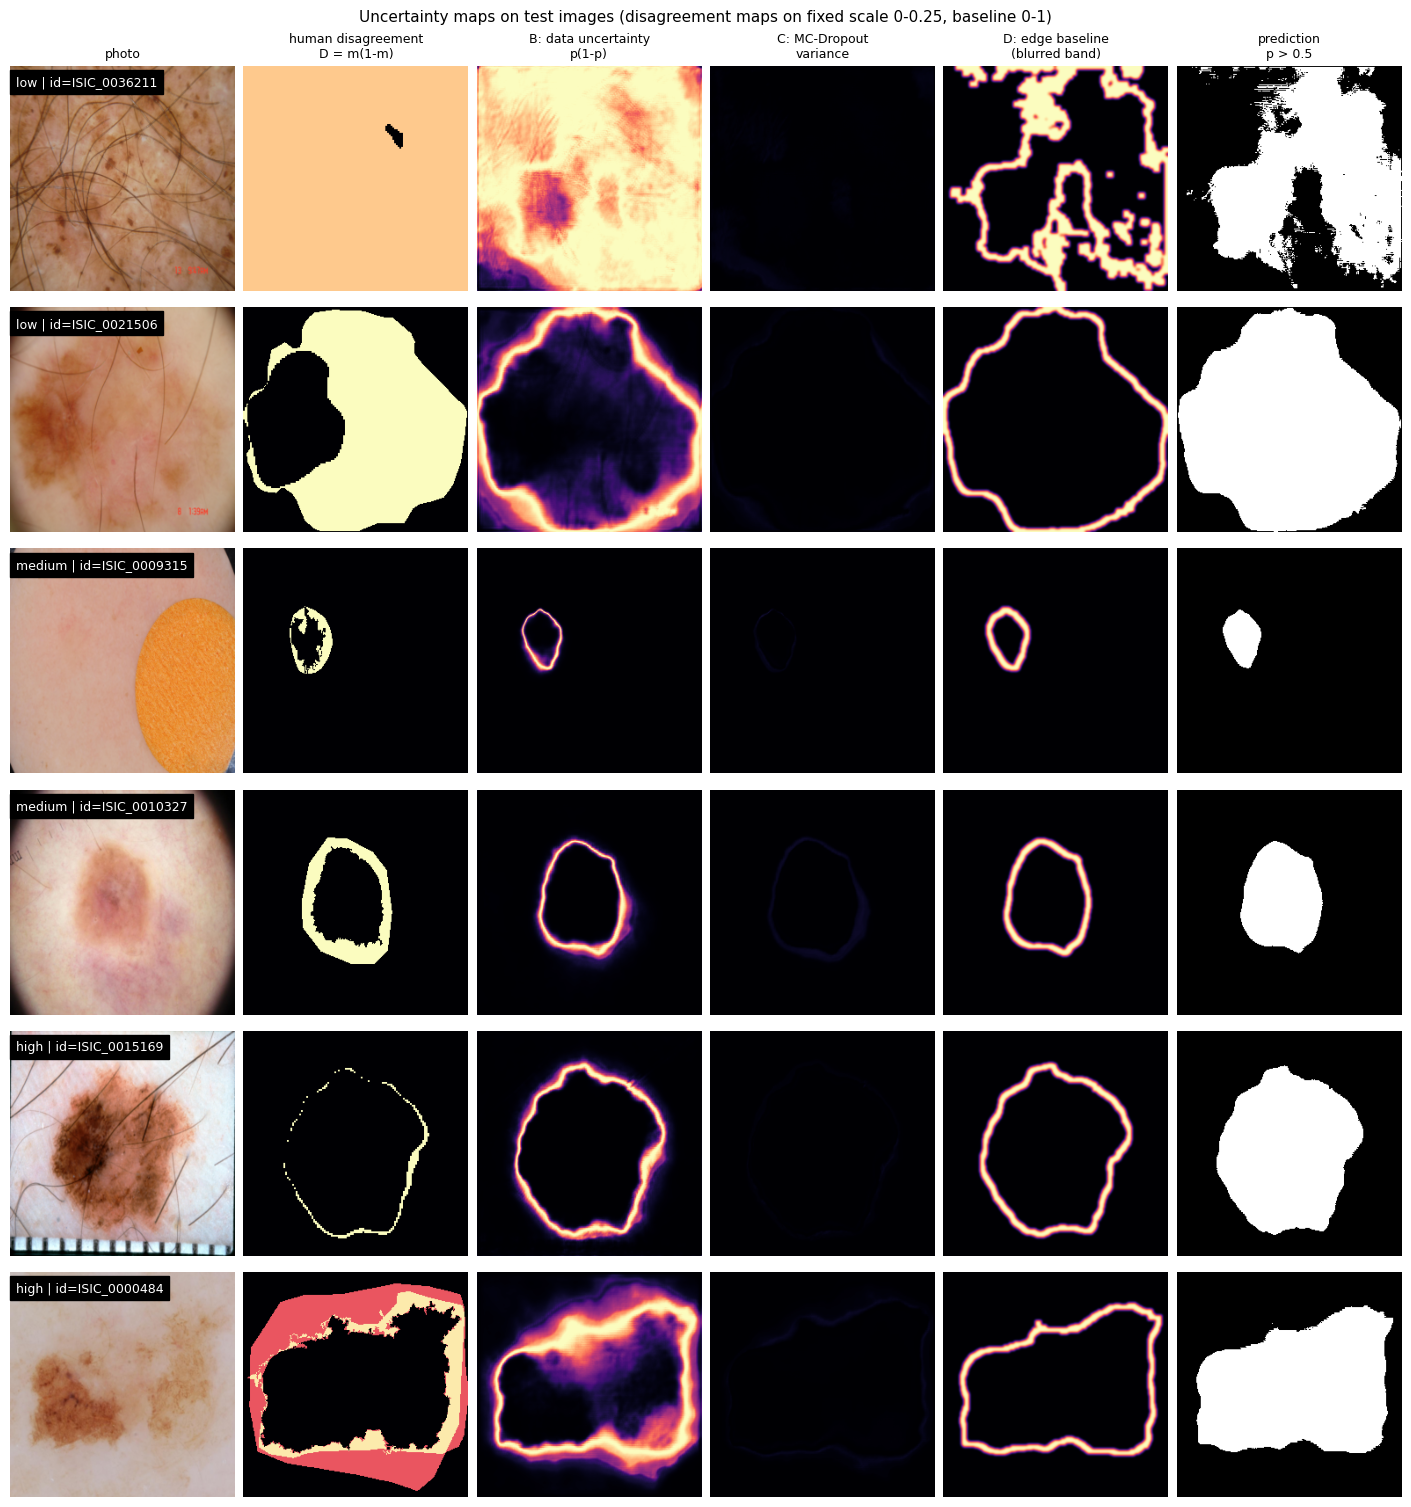

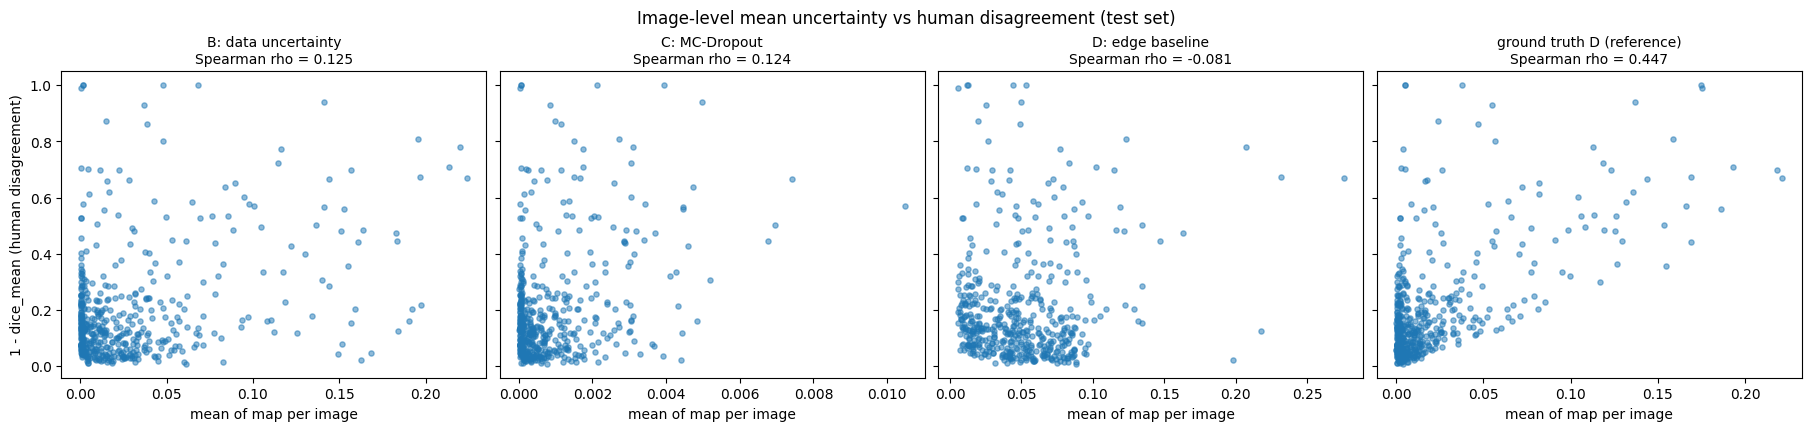

Saved figures:
 - /content/drive/MyDrive/IMA_project/uncertainty_examples_grid.png
 - /content/drive/MyDrive/IMA_project/uncertainty_vs_disagreement_scatter.png


In [ ]:
# ============================================================
# CELL 6 - Figures (saved to Drive)
# ============================================================
# Requires cell 5 (R and keep_maps).

# ---------- (i) grid: 2 low + 2 medium + 2 high agreement test images ----------
rng = np.random.default_rng(123)      # fixed seed -> reproducible choice, not hand-picked
picked = []
for v in ["low", "medium", "high"]:
    cand = np.where(R["dice_range"] == v)[0]
    if len(cand) > 0:
        picked += list(rng.choice(cand, size=min(2, len(cand)), replace=False))
print("Selected test positions:", picked,
      "| dice_range:", [R["dice_range"][p] for p in picked])

col_titles = ["photo", "human disagreement\nD = m(1-m)",
              "B: data uncertainty\np(1-p)", "C: MC-Dropout\nvariance",
              "D: edge baseline\n(blurred band)", "prediction\np > 0.5"]
fig, axes = plt.subplots(len(picked), 6, figsize=(14, 2.5 * len(picked)),
                         constrained_layout=True)
axes = np.atleast_2d(axes)
for r, pos in enumerate(picked):
    i = int(R["idx"][pos])
    panels = [X[i], keep_maps["gt"][pos], keep_maps["data_unc"][pos],
              keep_maps["mc_dropout"][pos], keep_maps["edge_base"][pos],
              keep_maps["pred"][pos]]
    for c in range(6):
        ax = axes[r, c]
        if c == 0:
            ax.imshow(panels[0])
            ax.text(6, 22, f"{R['dice_range'][pos]} | id={ids[i]}", fontsize=9,
                    color="white", backgroundcolor="black")
        elif c == 5:
            ax.imshow(panels[c], cmap="gray", vmin=0, vmax=1)
        else:
            # disagreement-type maps live in [0, 0.25]; the baseline is normalized to 0-1
            vmax = 0.25 if c in (1, 2, 3) else 1.0
            ax.imshow(panels[c], cmap="magma", vmin=0, vmax=vmax)
        if r == 0:
            ax.set_title(col_titles[c], fontsize=9)
        ax.axis("off")
fig.suptitle("Uncertainty maps on test images "
             "(disagreement maps on fixed scale 0-0.25, baseline 0-1)", fontsize=11)
plt.savefig(os.path.join(DRIVE_DIR, "uncertainty_examples_grid.png"), dpi=150)
plt.show()

# ---------- (ii) scatter: image-level mean uncertainty vs (1 - dice_mean) ----------
y = 1.0 - R["dice_mean"]
panels = [("B: data uncertainty", "mean_data_unc"),
          ("C: MC-Dropout", "mean_mc_dropout"),
          ("D: edge baseline", "mean_edge_base"),
          ("ground truth D (reference)", "mean_gt")]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), constrained_layout=True, sharey=True)
for c, (name, key) in enumerate(panels):
    x = R[key].astype(np.float64)
    rho = spearman_safe(x, y)
    axes[c].scatter(x, y, s=14, alpha=0.5)
    axes[c].set_xlabel("mean of map per image")
    axes[c].set_title(f"{name}\nSpearman rho = {rho:.3f}", fontsize=10)
axes[0].set_ylabel("1 - dice_mean (human disagreement)")
fig.suptitle("Image-level mean uncertainty vs human disagreement (test set)", fontsize=12)
plt.savefig(os.path.join(DRIVE_DIR, "uncertainty_vs_disagreement_scatter.png"), dpi=150)
plt.show()

print("Saved figures:")
for f in ["uncertainty_examples_grid.png", "uncertainty_vs_disagreement_scatter.png"]:
    print(" -", os.path.join(DRIVE_DIR, f))

In [ ]:
# CELL 7 Presentation only: MC-Dropout panels drawn on their own scale. No metrics change.
import numpy as np, matplotlib.pyplot as plt, os
mc_max = [float(m.astype(np.float32).max()) for m in keep_maps["mc_dropout"]]
print("MC-Dropout variance: median of per-image max =", round(float(np.median(mc_max)), 4),
      "| overall max =", round(max(mc_max), 4))

fig, axes = plt.subplots(len(picked), 4, figsize=(11, 2.6 * len(picked)), constrained_layout=True)
for r, pos in enumerate(picked):
    i = int(R["idx"][pos])
    mc = keep_maps["mc_dropout"][pos].astype(np.float32)
    axes[r, 0].imshow(X[i]);  axes[r, 0].set_title(f"{R['dice_range'][pos]} | {ids[i]}", fontsize=8)
    axes[r, 1].imshow(keep_maps["gt"][pos], cmap="magma", vmin=0, vmax=0.25)
    axes[r, 2].imshow(keep_maps["data_unc"][pos], cmap="magma", vmin=0, vmax=0.25)
    axes[r, 3].imshow(mc, cmap="magma", vmin=0, vmax=max(float(np.percentile(mc, 99.5)), 1e-6))
    if r == 0:
        for c, t in enumerate(["photo", "human disagreement", "B: data uncertainty", "C: MC-Dropout\n(own scale per image)"]):
            axes[r, c].set_title(t if c else axes[r, 0].get_title(), fontsize=8)
    for a in axes[r]: a.axis("off")
plt.savefig("/content/drive/MyDrive/IMA_project/mc_dropout_own_scale.png", dpi=150)
plt.show()

In [ ]:
# CELL 8
import numpy as np, pandas as pd
from scipy import stats

rng = np.random.default_rng(0)
NB = 2000   # number of bootstrap resamples
A = {"B": R["auc_data_unc"], "C": R["auc_mc_dropout"], "E": R["auc_edge_base"]}

groups = {"all": np.ones(len(A["B"]), bool)}
for v in ["high", "medium", "low"]:
    groups[v] = R["dice_range"] == v
for v in ["benign", "malignant"]:
    groups[v] = R["malignancy"] == v

def ci(x):
    lo, hi = np.percentile(x, [2.5, 97.5])
    return lo, hi

rows = []
for name, sel in groups.items():
    idx = np.where(sel)[0]
    n = len(idx)
    res = {"B": [], "C": [], "E": [], "B-E": [], "B-C": []}
    for _ in range(NB):
        s = rng.choice(idx, size=n, replace=True)
        b, c, e = np.nanmean(A["B"][s]), np.nanmean(A["C"][s]), np.nanmean(A["E"][s])
        res["B"].append(b); res["C"].append(c); res["E"].append(e)
        res["B-E"].append(b - e); res["B-C"].append(b - c)
    row = {"group": name, "n": n}
    for k in "BCE":
        lo, hi = ci(res[k])
        row[f"AUC_{k} [95% CI]"] = f"{np.nanmean(A[k][idx]):.3f} [{lo:.3f}, {hi:.3f}]"
    for k in ["B-E", "B-C"]:
        lo, hi = ci(res[k])
        d = np.nanmean(A[k[0]][idx]) - np.nanmean(A[k[2]][idx])
        row[f"diff {k} [95% CI]"] = f"{d:+.3f} [{lo:+.3f}, {hi:+.3f}]"
    rows.append(row)

out = pd.DataFrame(rows)
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
print(out.to_string(index=False))
out.to_csv("/content/drive/MyDrive/IMA_project/bootstrap_ci_auc.csv", index=False)

# Overall Dice and image-level Spearman, with CIs
dice = R["dice_pred_vs_ann"]
d_bs = [dice[rng.choice(len(dice), len(dice))].mean() for _ in range(NB)]
print(f"\nDice vs annotators: {dice.mean():.3f} [{ci(d_bs)[0]:.3f}, {ci(d_bs)[1]:.3f}]")
y = 1 - R["dice_mean"]
for name, key in [("B", "mean_data_unc"), ("C", "mean_mc_dropout")]:
    m = R[key]
    sp = []
    for _ in range(NB):
        s = rng.choice(len(y), len(y))
        sp.append(stats.spearmanr(m[s], y[s])[0])
    print(f"Image-level Spearman ({name}): {stats.spearmanr(m, y)[0]:.3f} [{ci(sp)[0]:.3f}, {ci(sp)[1]:.3f}]")

    group   n       AUC_B [95% CI]       AUC_C [95% CI]       AUC_E [95% CI]       diff B-E [95% CI]       diff B-C [95% CI]
      all 479 0.915 [0.903, 0.926] 0.849 [0.833, 0.865] 0.872 [0.859, 0.886] +0.043 [+0.035, +0.051] +0.066 [+0.055, +0.078]
     high 317 0.945 [0.935, 0.954] 0.885 [0.870, 0.901] 0.922 [0.910, 0.934] +0.023 [+0.016, +0.029] +0.059 [+0.048, +0.071]
   medium 115 0.881 [0.852, 0.907] 0.802 [0.762, 0.839] 0.825 [0.797, 0.852] +0.056 [+0.035, +0.077] +0.079 [+0.053, +0.106]
      low  47 0.799 [0.745, 0.849] 0.718 [0.659, 0.776] 0.655 [0.613, 0.699] +0.144 [+0.106, +0.180] +0.081 [+0.041, +0.122]
   benign 377 0.930 [0.917, 0.941] 0.877 [0.861, 0.893] 0.900 [0.886, 0.914] +0.030 [+0.021, +0.039] +0.053 [+0.042, +0.063]
malignant 101 0.859 [0.830, 0.887] 0.743 [0.702, 0.784] 0.771 [0.740, 0.801] +0.088 [+0.072, +0.105] +0.116 [+0.085, +0.149]

Dice vs annotators: 0.852 [0.839, 0.864]
Image-level Spearman (B): 0.125 [0.038, 0.210]
Image-level Spearman (C): 0.124 [0.0

In [ ]:
# CELL 9===== EXTRA TRAINING RUN: same settings as the first run, only the random seed differs =====
SEED_RUN = 1          # change to 2 for the next run; change nothing else
EPOCHS, LR = 30, 1e-4

random.seed(SEED_RUN); np.random.seed(SEED_RUN)
torch.manual_seed(SEED_RUN); torch.cuda.manual_seed_all(SEED_RUN)

CK_LAST = os.path.join(DRIVE_DIR, f"seed{SEED_RUN}_ckpt_last.pt")
CK_BEST = os.path.join(DRIVE_DIR, f"seed{SEED_RUN}_ckpt_best.pt")

g = torch.Generator(); g.manual_seed(SEED_RUN)
train_dl = DataLoader(LesionDataset(train_idx, train=True), batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, generator=g, worker_init_fn=seed_worker)

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1, activation=None)
model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT_P), model.segmentation_head)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)

history = {"train_loss": [], "val_loss": []}
start_epoch, best_val = 1, float("inf")
if os.path.exists(CK_LAST):                      # resume after a disconnect
    ck = torch.load(CK_LAST, map_location=device)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scaler.load_state_dict(ck["scaler"])
    start_epoch, best_val, history = ck["epoch"] + 1, ck["best_val"], ck["history"]
    print("Resumed after epoch", ck["epoch"])

def save_ckpt(payload, path):
    torch.save(payload, "/content/_tmp_ckpt.pt")
    shutil.copy2("/content/_tmp_ckpt.pt", path)

def run_epoch(loader, training, desc):
    model.train(training)
    tot, nb = 0.0, 0
    with torch.set_grad_enabled(training):
        for img, msk, _ in tqdm(loader, desc=desc, leave=False):
            img = img.to(device, non_blocking=True); msk = msk.to(device, non_blocking=True)
            with torch.autocast("cuda", enabled=use_amp):
                loss = combined_loss(model(img), msk)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            tot += loss.item(); nb += 1
    return tot / max(nb, 1)

t0 = time.time()
for epoch in range(start_epoch, EPOCHS + 1):
    tr = run_epoch(train_dl, True,  f"train ep{epoch}")
    va = run_epoch(val_dl,   False, f"val ep{epoch}")
    history["train_loss"].append(tr); history["val_loss"].append(va)
    is_best = va < best_val
    best_val = min(best_val, va)
    payload = {"epoch": epoch, "best_val": best_val, "history": history,
               "model": model.state_dict(), "optimizer": optimizer.state_dict(),
               "scaler": scaler.state_dict()}
    save_ckpt(payload, CK_LAST)
    if is_best: save_ckpt(payload, CK_BEST)
    print(f"seed {SEED_RUN} | epoch {epoch:2d}/{EPOCHS} | train {tr:.4f} | val {va:.4f} "
          f"| best {best_val:.4f}{' *' if is_best else ''} | {time.time()-t0:.0f}s")
print("Finished. Best val loss:", round(best_val, 4))

train ep1:   0%|          | 0/105 [00:00<?, ?it/s]

val ep1:   0%|          | 0/15 [00:00<?, ?it/s]

seed 1 | epoch  1/30 | train 0.9997 | val 0.7473 | best 0.7473 * | 51s


train ep2:   0%|          | 0/105 [00:00<?, ?it/s]

val ep2:   0%|          | 0/15 [00:00<?, ?it/s]

...

val ep29:   0%|          | 0/15 [00:00<?, ?it/s]

seed 1 | epoch 29/30 | train 0.3096 | val 0.3226 | best 0.3159 | 1421s


train ep30:   0%|          | 0/105 [00:00<?, ?it/s]

val ep30:   0%|          | 0/15 [00:00<?, ?it/s]

seed 1 | epoch 30/30 | train 0.3026 | val 0.3263 | best 0.3159 | 1463s
Finished. Best val loss: 0.3159


In [ ]:
# ===== EXTRA TRAINING RUN: same settings as the first run, only the random seed differs =====
SEED_RUN = 2          # change to 2 for the next run; change nothing else
EPOCHS, LR = 30, 1e-4

random.seed(SEED_RUN); np.random.seed(SEED_RUN)
torch.manual_seed(SEED_RUN); torch.cuda.manual_seed_all(SEED_RUN)

CK_LAST = os.path.join(DRIVE_DIR, f"seed{SEED_RUN}_ckpt_last.pt")
CK_BEST = os.path.join(DRIVE_DIR, f"seed{SEED_RUN}_ckpt_best.pt")

g = torch.Generator(); g.manual_seed(SEED_RUN)
train_dl = DataLoader(LesionDataset(train_idx, train=True), batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, generator=g, worker_init_fn=seed_worker)

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                 in_channels=3, classes=1, activation=None)
model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT_P), model.segmentation_head)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)

history = {"train_loss": [], "val_loss": []}
start_epoch, best_val = 1, float("inf")
if os.path.exists(CK_LAST):                      # resume after a disconnect
    ck = torch.load(CK_LAST, map_location=device)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scaler.load_state_dict(ck["scaler"])
    start_epoch, best_val, history = ck["epoch"] + 1, ck["best_val"], ck["history"]
    print("Resumed after epoch", ck["epoch"])

def save_ckpt(payload, path):
    torch.save(payload, "/content/_tmp_ckpt.pt")
    shutil.copy2("/content/_tmp_ckpt.pt", path)

def run_epoch(loader, training, desc):
    model.train(training)
    tot, nb = 0.0, 0
    with torch.set_grad_enabled(training):
        for img, msk, _ in tqdm(loader, desc=desc, leave=False):
            img = img.to(device, non_blocking=True); msk = msk.to(device, non_blocking=True)
            with torch.autocast("cuda", enabled=use_amp):
                loss = combined_loss(model(img), msk)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            tot += loss.item(); nb += 1
    return tot / max(nb, 1)

t0 = time.time()
for epoch in range(start_epoch, EPOCHS + 1):
    tr = run_epoch(train_dl, True,  f"train ep{epoch}")
    va = run_epoch(val_dl,   False, f"val ep{epoch}")
    history["train_loss"].append(tr); history["val_loss"].append(va)
    is_best = va < best_val
    best_val = min(best_val, va)
    payload = {"epoch": epoch, "best_val": best_val, "history": history,
               "model": model.state_dict(), "optimizer": optimizer.state_dict(),
               "scaler": scaler.state_dict()}
    save_ckpt(payload, CK_LAST)
    if is_best: save_ckpt(payload, CK_BEST)
    print(f"seed {SEED_RUN} | epoch {epoch:2d}/{EPOCHS} | train {tr:.4f} | val {va:.4f} "
          f"| best {best_val:.4f}{' *' if is_best else ''} | {time.time()-t0:.0f}s")
print("Finished. Best val loss:", round(best_val, 4))

train ep1:   0%|          | 0/105 [00:00<?, ?it/s]

val ep1:   0%|          | 0/15 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783ce4ad3240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionErrorException ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x783ce4ad3240>: 
Traceback (most recent call last):
can only test a child process  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

seed 2 | epoch  1/30 | train 0.9822 | val 0.7269 | best 0.7269 * | 22s


train ep2:   0%|          | 0/105 [00:00<?, ?it/s]

...

val ep29:   0%|          | 0/15 [00:00<?, ?it/s]

seed 2 | epoch 29/30 | train 0.2963 | val 0.3281 | best 0.3217 | 1344s


train ep30:   0%|          | 0/105 [00:00<?, ?it/s]

val ep30:   0%|          | 0/15 [00:00<?, ?it/s]

seed 2 | epoch 30/30 | train 0.2951 | val 0.3204 | best 0.3204 * | 1397s
Finished. Best val loss: 0.3204


In [ ]:
# CELL 9===== VERSION 2 TEST EVALUATION: 3 trained models (seeds 42, 1, 2) + deep ensemble =====
# Fixed in advance. Do not edit settings or add/remove analyses after seeing the output.
import pickle
T_MC, EDGE_PX = 16, 3
CKPTS = {"seed42": f"{DRIVE_DIR}/ckpt_best.pt",
         "seed1":  f"{DRIVE_DIR}/seed1_ckpt_best.pt",
         "seed2":  f"{DRIVE_DIR}/seed2_ckpt_best.pt"}

def dice_np(a, b, eps=1e-6):
    d = a.sum() + b.sum()
    return 1.0 if d == 0 else float(2.0 * np.logical_and(a, b).sum() / (d + eps))

def pearson_D(mp, D):
    return np.nan if (mp.std() == 0 or D.std() == 0) else float(np.corrcoef(mp.ravel(), D.ravel())[0, 1])

def auc_dis(mp, m):
    lab = (m > 0) & (m < 1)
    if lab.all() or (~lab).all() or mp.std() == 0:
        return np.nan
    return float(roc_auc_score(lab.ravel(), mp.ravel()))

def edge_band(pred, hw=EDGE_PX):
    st = np.ones((3, 3), dtype=bool)
    band = (ndimage.binary_dilation(pred, structure=st, iterations=hw) &
            ~ndimage.binary_erosion(pred, structure=st, iterations=hw)).astype(np.float32)
    if band.max() > 0:
        band = ndimage.gaussian_filter(band, sigma=1.5)
        if band.max() > 0:
            band = band / band.max()
    return band.astype(np.float32)

def sp(a, b):
    r = stats.spearmanr(a, b)
    return float(getattr(r, "statistic", getattr(r, "correlation", np.nan)))

def build_model():
    mdl = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1, activation=None)
    mdl.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT_P), mdl.segmentation_head)
    return mdl.to(device)

TEST = [int(i) for i in test_idx]
nT = len(TEST)
MS = np.stack([soft_label(i) for i in TEST]).astype(np.float32)   # mean of the REAL outlines
DS = MS * (1 - MS)                                                # true disagreement
DM = np.array([float(dice_mean[i]) for i in TEST])
DR = np.array([str(dice_range[i]) for i in TEST])
MAL = np.array([str(malignancy[i]) for i in TEST])

def eval_model(path, tag):
    mdl = build_model()
    ck = torch.load(path, map_location=device)
    mdl.load_state_dict(ck["model"]); mdl.eval()
    print(f"{tag}: loaded epoch {ck['epoch']} (val loss {ck['best_val']:.4f})")
    torch.manual_seed(42)
    out = {k: np.zeros(nT) for k in ["dice", "auc_B", "auc_C", "auc_E", "pear_B", "pear_C", "pear_E",
                                      "mean_B", "mean_C", "mean_E"]}
    P = np.zeros((nT, 256, 256), np.float32)
    for n, i in enumerate(tqdm(TEST, desc=tag)):
        x = normalize_image(X[i]).unsqueeze(0).to(device)
        mdl.eval()
        with torch.no_grad():
            p = torch.sigmoid(mdl(x))[0, 0].cpu().numpy().astype(np.float32)
        for mod in mdl.modules():
            if isinstance(mod, (nn.Dropout, nn.Dropout2d)):
                mod.train()
        with torch.no_grad():
            pr = torch.sigmoid(mdl(x.repeat(T_MC, 1, 1, 1)))[:, 0]
            uc = pr.var(dim=0, unbiased=False).cpu().numpy().astype(np.float32)
        mdl.eval()
        ub, pred = p * (1 - p), p > 0.5
        ue = edge_band(pred)
        m, D = MS[n], DS[n]
        out["dice"][n] = np.mean([dice_np(pred, M[i, k] > 0) for k in range(int(K[i]))])
        for tg, mp in (("B", ub), ("C", uc), ("E", ue)):
            out[f"auc_{tg}"][n] = auc_dis(mp, m)
            out[f"pear_{tg}"][n] = pearson_D(mp, D)
            out[f"mean_{tg}"][n] = mp.mean()
        P[n] = p
    return out, P

per_seed, Ps = {}, []
for tag, path in CKPTS.items():
    per_seed[tag], P = eval_model(path, tag)
    Ps.append(P)
Pstack = np.stack(Ps); del Ps
Pbar, Pvar = Pstack.mean(axis=0), Pstack.var(axis=0); del Pstack

ens = {k: np.zeros(nT) for k in ["dice", "auc_B", "auc_V", "auc_E", "pear_B", "pear_V", "pear_E",
                                  "mean_B", "mean_V", "mean_E"]}
for n, i in enumerate(tqdm(TEST, desc="ensemble")):
    p = Pbar[n]; m, D = MS[n], DS[n]
    ub, uv = p * (1 - p), Pvar[n]
    pred = p > 0.5
    ue = edge_band(pred)
    ens["dice"][n] = np.mean([dice_np(pred, M[i, k] > 0) for k in range(int(K[i]))])
    for tg, mp in (("B", ub), ("V", uv), ("E", ue)):
        ens[f"auc_{tg}"][n] = auc_dis(mp, m)
        ens[f"pear_{tg}"][n] = pearson_D(mp, D)
        ens[f"mean_{tg}"][n] = mp.mean()

pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)

# ---- Table 1: each single model, overall ----
rows = []
for tag, o in per_seed.items():
    rows.append({"model": tag, "Dice": np.nanmean(o["dice"]),
                 "AUC_B": np.nanmean(o["auc_B"]), "AUC_C": np.nanmean(o["auc_C"]), "AUC_E": np.nanmean(o["auc_E"]),
                 "B-E": np.nanmean(o["auc_B"]) - np.nanmean(o["auc_E"]),
                 "B-C": np.nanmean(o["auc_B"]) - np.nanmean(o["auc_C"]),
                 "Pearson_B": np.nanmean(o["pear_B"]), "Pearson_C": np.nanmean(o["pear_C"]),
                 "Pearson_E": np.nanmean(o["pear_E"]),
                 "Spearman_B": sp(o["mean_B"], 1 - DM), "Spearman_C": sp(o["mean_C"], 1 - DM)})
t1 = pd.DataFrame(rows).set_index("model")
print("=== TABLE 1: single models (test set, overall) ===")
print(t1.round(4).to_string())
print("\nMean +/- SD over the 3 seeds:")
for c in t1.columns:
    print(f"  {c:11s} {t1[c].mean():.4f} +/- {t1[c].std(ddof=1):.4f}")
print("\nReproduction check, first run (seed42): earlier Dice 0.8519, AUC B 0.9151, C 0.8490, E 0.8725")

# ---- Table 2: deep ensemble, overall ----
print("\n=== TABLE 2: deep ensemble of the 3 models (test set, overall) ===")
print(f"Dice {np.nanmean(ens['dice']):.4f}")
for tg in "BVE":
    print(f"  ENS_{tg}: AUC {np.nanmean(ens['auc_'+tg]):.4f} | Pearson {np.nanmean(ens['pear_'+tg]):.4f} | "
          f"Spearman {sp(ens['mean_'+tg], 1 - DM):.4f}")

# ---- Table 3: subgroup AUCs ----
groups = {"all": np.ones(nT, bool), "high": DR == "high", "medium": DR == "medium",
          "low": DR == "low", "benign": MAL == "benign", "malignant": MAL == "malignant"}
rows = []
for g, sel in groups.items():
    r = {"group": g, "n": int(sel.sum())}
    for key, nm in (("auc_B", "B"), ("auc_C", "C"), ("auc_E", "E")):
        v = [np.nanmean(o[key][sel]) for o in per_seed.values()]
        r[f"{nm} (mean+/-SD, 3 seeds)"] = f"{np.mean(v):.3f} +/- {np.std(v, ddof=1):.3f}"
    for key, nm in (("auc_B", "ENS_B"), ("auc_V", "ENS_V"), ("auc_E", "ENS_E")):
        r[nm] = f"{np.nanmean(ens[key][sel]):.3f}"
    rows.append(r)
t3 = pd.DataFrame(rows)
print("\n=== TABLE 3: AUC by subgroup ===")
print(t3.to_string(index=False))

# ---- Table 4: paired bootstrap differences (95% CI) ----
single_B = np.mean([o["auc_B"] for o in per_seed.values()], axis=0)
single_C = np.mean([o["auc_C"] for o in per_seed.values()], axis=0)
diffs = {"ENS_B - ENS_E": ens["auc_B"] - ens["auc_E"],
         "ENS_B - single B": ens["auc_B"] - single_B,
         "ENS_V - ENS_E": ens["auc_V"] - ens["auc_E"],
         "ENS_V - single C": ens["auc_V"] - single_C}
rng = np.random.default_rng(0)
def boot(d, sel, nb=2000):
    d = d[sel]; n = len(d)
    bs = [np.nanmean(d[rng.integers(0, n, n)]) for _ in range(nb)]
    return np.nanmean(d), np.percentile(bs, 2.5), np.percentile(bs, 97.5)
rows = []
for g in ["all", "low", "malignant"]:
    r = {"group": g}
    for name, d in diffs.items():
        mu, lo, hi = boot(d, groups[g])
        r[name] = f"{mu:+.3f} [{lo:+.3f}, {hi:+.3f}]"
    rows.append(r)
t4 = pd.DataFrame(rows)
print("\n=== TABLE 4: paired AUC differences with 95% bootstrap CI ===")
print(t4.to_string(index=False))

# ---- save everything to Drive ----
t1.to_csv(f"{DRIVE_DIR}/v2_single_models_overall.csv")
t3.to_csv(f"{DRIVE_DIR}/v2_subgroup_auc.csv", index=False)
t4.to_csv(f"{DRIVE_DIR}/v2_paired_differences.csv", index=False)
pickle.dump({"per_seed": per_seed, "ens": ens, "test_idx": TEST}, open(f"{DRIVE_DIR}/R_v2_seeds_ensemble.pkl", "wb"))
print("\nSaved v2 tables and per-image results to Drive.")

seed42: loaded epoch 26 (val loss 0.3150)


seed42:   0%|          | 0/479 [00:00<?, ?it/s]

seed1: loaded epoch 28 (val loss 0.3159)


seed1:   0%|          | 0/479 [00:00<?, ?it/s]

seed2: loaded epoch 30 (val loss 0.3204)


seed2:   0%|          | 0/479 [00:00<?, ?it/s]

ensemble:   0%|          | 0/479 [00:00<?, ?it/s]

=== TABLE 1: single models (test set, overall) ===
          Dice   AUC_B   AUC_C   AUC_E     B-E     B-C  Pearson_B  Pearson_C  Pearson_E  Spearman_B  Spearman_C
model                                                                                                          
seed42  0.8519  0.9151  0.8490  0.8725  0.0426  0.0661     0.4431     0.2815     0.4231      0.1250      0.1236
seed1   0.8521  0.9197  0.8531  0.8725  0.0472  0.0665     0.4421     0.3020     0.4191      0.1125      0.0800
seed2   0.8528  0.9249  0.8649  0.8682  0.0568  0.0600     0.4305     0.3331     0.4213      0.0848      0.0532

Mean +/- SD over the 3 seeds:
  Dice        0.8523 +/- 0.0005
  AUC_B       0.9199 +/- 0.0049
  AUC_C       0.8557 +/- 0.0083
  AUC_E       0.8710 +/- 0.0025
  B-E         0.0488 +/- 0.0072
  B-C         0.0642 +/- 0.0036
  Pearson_B   0.4386 +/- 0.0070
  Pearson_C   0.3055 +/- 0.0260
  Pearson_E   0.4212 +/- 0.0020
  Spearman_B  0.1075 +/- 0.0206
  Spearman_C  0.0856 +/- 0.0355

Repro

In [ ]:
#KEEP THIS ALSO
import numpy as np, pickle
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/IMA_project'
v2 = pickle.load(open(f'{D}/R_v2_seeds_ensemble.pkl', 'rb'))
d = np.load(f'{D}/ima_256.npz', allow_pickle=True)
y = 1 - d['dice_mean'][np.array(v2['test_idx'])].astype(float)   # how much annotators disagreed
ens = v2['ens']

def sp(a, b):
    r = stats.spearmanr(a, b)
    return float(getattr(r, 'statistic', getattr(r, 'correlation', np.nan)))

rng = np.random.default_rng(0)
maps = {'ENS_B': ens['mean_B'], 'ENS_V': ens['mean_V'], 'ENS_E': ens['mean_E']}
bs = {k: [] for k in maps}; diff = []
for _ in range(2000):
    s = rng.integers(0, len(y), len(y))
    for k, x in maps.items():
        bs[k].append(sp(x[s], y[s]))
    diff.append(bs['ENS_V'][-1] - bs['ENS_B'][-1])
for k, x in maps.items():
    lo, hi = np.percentile(bs[k], [2.5, 97.5])
    print(f"Image-level Spearman {k}: {sp(x, y):.3f} [{lo:.3f}, {hi:.3f}]")
lo, hi = np.percentile(diff, [2.5, 97.5])
print(f"ENS_V minus ENS_B: {sp(maps['ENS_V'], y) - sp(maps['ENS_B'], y):+.3f} [{lo:+.3f}, {hi:+.3f}]")

Mounted at /content/drive
Image-level Spearman ENS_B: 0.127 [0.032, 0.216]
Image-level Spearman ENS_V: 0.235 [0.145, 0.321]
Image-level Spearman ENS_E: -0.135 [-0.222, -0.049]
ENS_V minus ENS_B: +0.108 [+0.067, +0.148]


In [ ]:
# CELL 11 KEEP THIS ALSO ===== IMAGE-LEVEL AGREEMENT PREDICTOR: photo -> expected annotator agreement (dice_mean) =====
# Needs Cells 1 and 2 run in this session. Fixed in advance. Epoch chosen on VALIDATION only.
import torchvision, pickle
from torch.utils.data import DataLoader, Dataset

EPOCHS_A, LR_A, BS_A, SEEDS_A = 20, 1e-4, 32, [42, 1, 2]
use_amp = device.type == "cuda"

def sp(a, b):
    r = stats.spearmanr(a, b)
    return float(getattr(r, "statistic", getattr(r, "correlation", np.nan)))

class AgreeDS(Dataset):
    def __init__(self, idx, train):
        self.idx, self.train = np.asarray(idx), train
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, n):
        i = int(self.idx[n]); x = X[i]
        if self.train:                                  # flips/rotations only (the target does not change)
            if random.random() < 0.5: x = x[:, ::-1]
            if random.random() < 0.5: x = x[::-1]
            k = random.randint(0, 3)
            if k: x = np.rot90(x, k)
            x = np.ascontiguousarray(x)
        return normalize_image(x), torch.tensor(float(dice_mean[i]), dtype=torch.float32)

def make_net():
    m = torchvision.models.resnet34(weights="IMAGENET1K_V1")
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(512, 1))
    return m.to(device)

def predict(net, idx):
    net.eval(); out = []
    dl = DataLoader(AgreeDS(idx, False), batch_size=64, shuffle=False, num_workers=2)
    with torch.no_grad():
        for xb, _ in dl:
            out.append(torch.sigmoid(net(xb.to(device))).squeeze(1).float().cpu())
    return torch.cat(out).numpy()

# ---------------- training: 3 seeds, best epoch by VALIDATION Spearman ----------------
for s in SEEDS_A:
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    g = torch.Generator(); g.manual_seed(s)
    dl = DataLoader(AgreeDS(train_idx, True), batch_size=BS_A, shuffle=True, num_workers=2,
                    generator=g, worker_init_fn=seed_worker)
    net = make_net()
    opt = torch.optim.Adam(net.parameters(), lr=LR_A)
    scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)
    best, best_ep, t0 = -9.0, 0, time.time()
    for ep in range(1, EPOCHS_A + 1):
        net.train(); tl, nb = 0.0, 0
        for xb, yb in tqdm(dl, leave=False, desc=f"seed{s} ep{ep}"):
            xb, yb = xb.to(device), yb.to(device)
            with torch.autocast("cuda", enabled=use_amp):
                pr = torch.sigmoid(net(xb)).squeeze(1)
            loss = F.mse_loss(pr.float(), yb)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item(); nb += 1
        pv = predict(net, val_idx)
        rho = sp(pv, dice_mean[val_idx])
        if rho > best:
            best, best_ep = rho, ep
            torch.save(net.state_dict(), f"{DRIVE_DIR}/iaa_seed{s}_best.pt")
        print(f"seed {s} | epoch {ep:2d}/{EPOCHS_A} | train mse {tl/nb:.4f} | val Spearman {rho:.3f} "
              f"| best {best:.3f} (ep {best_ep}) | {time.time()-t0:.0f}s")

# ---------------- test evaluation (first and only look at the test set for this model) ----------------
v2 = pickle.load(open(f"{DRIVE_DIR}/R_v2_seeds_ensemble.pkl", "rb"))
assert [int(i) for i in test_idx] == [int(i) for i in v2["test_idx"]], "test order mismatch"
y_dis = 1 - dice_mean[test_idx].astype(float)                       # how much annotators disagreed
is_low = np.array([str(dice_range[i]) == "low" for i in test_idx])

preds = []
for s in SEEDS_A:
    net = make_net(); net.load_state_dict(torch.load(f"{DRIVE_DIR}/iaa_seed{s}_best.pt", map_location=device))
    preds.append(predict(net, test_idx))
preds = np.stack(preds)
score_seed = {f"predictor seed{s}": 1 - preds[k] for k, s in enumerate(SEEDS_A)}
score_ens = 1 - preds.mean(axis=0)                                  # predicted disagreement, 3-model average
base = {"ENS_V (model spread)": v2["ens"]["mean_V"], "ENS_B (soft-label map)": v2["ens"]["mean_B"],
        "ENS_E (edge baseline)": v2["ens"]["mean_E"]}

def auc_low(sc): return float(roc_auc_score(is_low, sc))
rng = np.random.default_rng(0)
B = [rng.integers(0, len(y_dis), len(y_dis)) for _ in range(2000)]
def ci_sp(sc): return np.percentile([sp(sc[b], y_dis[b]) for b in B], [2.5, 97.5])
def ci_auc(sc): return np.percentile([roc_auc_score(is_low[b], sc[b]) for b in B if is_low[b].any() and (~is_low[b]).any()], [2.5, 97.5])

print("\n=== TEST: how well does each score rank images by annotator disagreement? ===")
print(f"{'score':28s} {'Spearman [95% CI]':26s} {'AUC for low-agreement images [95% CI]'}")
allsc = {**score_seed, "predictor ensemble (3)": score_ens, **base}
for name, sc in allsc.items():
    lo, hi = ci_sp(sc); alo, ahi = ci_auc(sc)
    print(f"{name:28s} {sp(sc, y_dis):.3f} [{lo:.3f}, {hi:.3f}]      {auc_low(sc):.3f} [{alo:.3f}, {ahi:.3f}]")

d = [sp(score_ens[b], y_dis[b]) - sp(base['ENS_V (model spread)'][b], y_dis[b]) for b in B]
dl_, dh_ = np.percentile(d, [2.5, 97.5])
print(f"\nPredictor ensemble minus ENS_V (Spearman): {sp(score_ens, y_dis) - sp(base['ENS_V (model spread)'], y_dis):+.3f} [{dl_:+.3f}, {dh_:+.3f}]")
pickle.dump({"preds": preds, "seeds": SEEDS_A}, open(f"{DRIVE_DIR}/iaa_test_predictions.pkl", "wb"))
print("Saved predictions to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


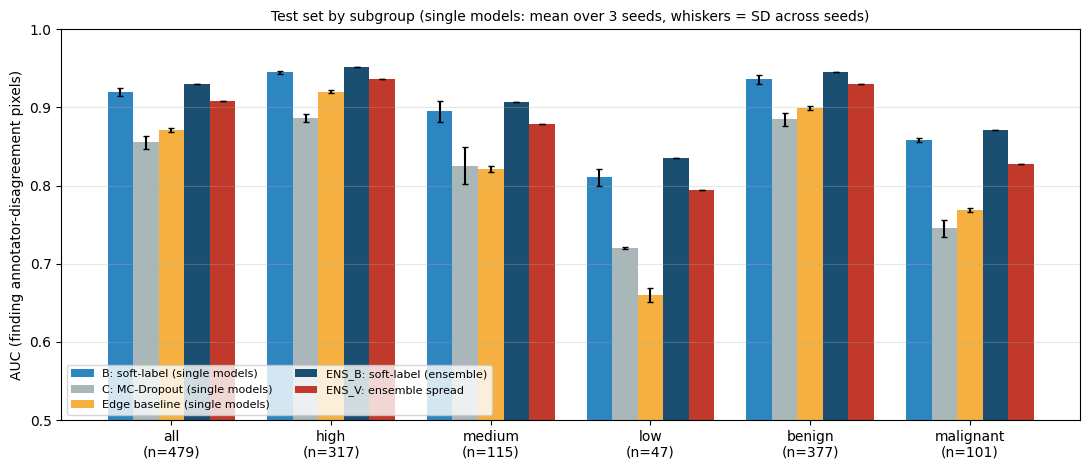

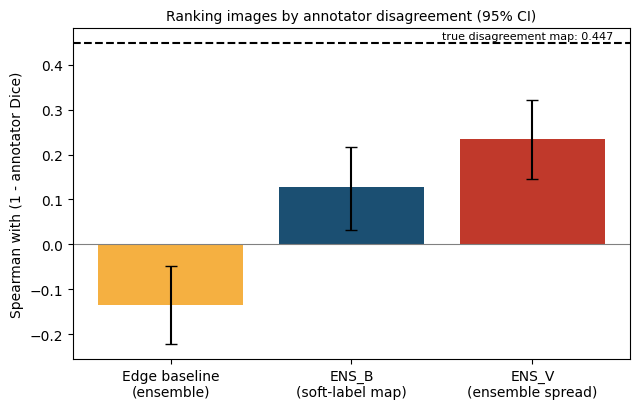

True-disagreement-map reference (Spearman): 0.447


In [ ]:
#CELL 12 KEEP THIS
import numpy as np, pickle, matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/IMA_project'
v2 = pickle.load(open(f'{D}/R_v2_seeds_ensemble.pkl', 'rb'))
d = np.load(f'{D}/ima_256.npz', allow_pickle=True)
idx = np.array(v2['test_idx'])
DR, MAL = d['dice_range'][idx].astype(str), d['malignancy'][idx].astype(str)
y = 1 - d['dice_mean'][idx].astype(float)
per, ens = v2['per_seed'], v2['ens']

# ---------- Figure 1: AUC by subgroup ----------
groups = {'all': np.ones(len(idx), bool), 'high': DR == 'high', 'medium': DR == 'medium',
          'low': DR == 'low', 'benign': MAL == 'benign', 'malignant': MAL == 'malignant'}
names = list(groups)
series = [('B: soft-label (single models)', 'auc_B', True, '#2E86C1'),
          ('C: MC-Dropout (single models)', 'auc_C', True, '#AAB7B8'),
          ('Edge baseline (single models)', 'auc_E', True, '#F5B041'),
          ('ENS_B: soft-label (ensemble)', 'auc_B', False, '#1B4F72'),
          ('ENS_V: ensemble spread', 'auc_V', False, '#C0392B')]
fig, ax = plt.subplots(figsize=(11, 4.8))
w = 0.16
for k, (lab, key, single, col) in enumerate(series):
    mu, sd = [], []
    for g in names:
        sel = groups[g]
        if single:
            v = [np.nanmean(o[key][sel]) for o in per.values()]
            mu.append(np.mean(v)); sd.append(np.std(v, ddof=1))
        else:
            mu.append(np.nanmean(ens[key][sel])); sd.append(0)
    ax.bar(np.arange(len(names)) + (k - 2) * w, mu, w, yerr=sd, label=lab, color=col, capsize=2)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([f"{g}\n(n={int(groups[g].sum())})" for g in names])
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUC (finding annotator-disagreement pixels)')
ax.set_title('Test set by subgroup (single models: mean over 3 seeds, whiskers = SD across seeds)', fontsize=10)
ax.legend(fontsize=8, ncol=2, loc='lower left'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{D}/auc_by_subgroup.png', dpi=170); plt.show()

# ---------- Figure 2: image-level Spearman ----------
def sp(a, b):
    r = stats.spearmanr(a, b)
    return float(getattr(r, 'statistic', getattr(r, 'correlation', np.nan)))
K = d['K'][idx]; Mt = d['M'][idx]
m = np.stack([Mt[n, :int(K[n])].astype(np.float32).mean(0) for n in range(len(idx))])
gt = sp((m * (1 - m)).mean(axis=(1, 2)), y)
rng = np.random.default_rng(0)
Bs = [rng.integers(0, len(y), len(y)) for _ in range(2000)]
items = [('Edge baseline\n(ensemble)', ens['mean_E']), ('ENS_B\n(soft-label map)', ens['mean_B']),
         ('ENS_V\n(ensemble spread)', ens['mean_V'])]
vals, los, his = [], [], []
for _, x in items:
    v = sp(x, y); bs = [sp(x[b], y[b]) for b in Bs]
    vals.append(v); los.append(v - np.percentile(bs, 2.5)); his.append(np.percentile(bs, 97.5) - v)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(range(3), vals, yerr=[los, his], color=['#F5B041', '#1B4F72', '#C0392B'], capsize=4)
ax.axhline(gt, ls='--', color='k'); ax.text(2.45, gt + 0.01, f'true disagreement map: {gt:.3f}', ha='right', fontsize=8)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(range(3)); ax.set_xticklabels([n for n, _ in items])
ax.set_ylabel('Spearman with (1 - annotator Dice)')
ax.set_title('Ranking images by annotator disagreement (95% CI)', fontsize=10)
plt.tight_layout(); plt.savefig(f'{D}/image_level_spearman.png', dpi=170); plt.show()
print('True-disagreement-map reference (Spearman):', round(gt, 3))

In [ ]:
# ===== FINAL CHECKS AND TABLES (needs only Google Drive) =====
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, pickle
from scipy import stats
from sklearn.metrics import roc_auc_score
D = '/content/drive/MyDrive/IMA_project'

def sp(a, b):
    r = stats.spearmanr(a, b)
    return float(getattr(r, 'statistic', getattr(r, 'correlation', np.nan)))
def ci(v): return np.percentile(v, [2.5, 97.5])

v2 = pickle.load(open(f'{D}/R_v2_seeds_ensemble.pkl', 'rb'))
pr = pickle.load(open(f'{D}/iaa_test_predictions.pkl', 'rb'))
d = np.load(f'{D}/ima_256.npz', allow_pickle=True)
idx = np.array(v2['test_idx'])
y = 1 - d['dice_mean'][idx].astype(float)
is_low = d['dice_range'][idx].astype(str) == 'low'
per, ens = v2['per_seed'], v2['ens']
score_pred = 1 - pr['preds'].mean(axis=0)

# ---------- PART 1: do val/test images share patients or lesions with training images? ----------
print("PART 1: overlap between the official splits")
meta = pd.read_csv(f'{D}/img_metadata.csv').rename(columns={'isic_id': 'image'})
tbl = pd.DataFrame({'image': d['id'].astype(str), 'split': d['split'].astype(str)})
tbl = tbl.merge(meta[['image', 'lesion_id', 'patient_id']], on='image', how='left')
train = tbl[tbl['split'] == 'train']
tr_les, tr_pat = set(train['lesion_id'].dropna()), set(train['patient_id'].dropna())
for key, tr in [('lesion_id', tr_les), ('patient_id', tr_pat)]:
    known = tbl[tbl[key].notna()]
    print(f"{key}: known for {len(known)} of {len(tbl)} images")
    for s in ['val', 'test']:
        part = known[known['split'] == s]
        print(f"   {s}: {int(part[key].isin(tr).sum())} of {len(part)} images share a {key} with a training image")

# ---------- PART 2: how well does each score rank images by annotator disagreement? ----------
print("\nPART 2: image-level ranking (test set)")
scores = {f'predictor seed{s}': 1 - pr['preds'][k] for k, s in enumerate(pr['seeds'])}
scores['predictor ensemble (3)'] = score_pred
scores['ENS_V (model spread)'] = ens['mean_V']
scores['ENS_B (soft-label map)'] = ens['mean_B']
scores['ENS_E (edge baseline)'] = ens['mean_E']
rng = np.random.default_rng(0)
Bs = [rng.integers(0, len(y), len(y)) for _ in range(2000)]
print(f"{'score':28s} {'Spearman [95% CI]':28s} AUC for low-agreement images [95% CI]")
for name, sc in scores.items():
    bs = [sp(sc[b], y[b]) for b in Bs]
    ba = [roc_auc_score(is_low[b], sc[b]) for b in Bs if is_low[b].any() and (~is_low[b]).any()]
    print(f"{name:28s} {sp(sc, y):.3f} [{ci(bs)[0]:.3f}, {ci(bs)[1]:.3f}]      "
          f"{roc_auc_score(is_low, sc):.3f} [{ci(ba)[0]:.3f}, {ci(ba)[1]:.3f}]")
dd = [sp(score_pred[b], y[b]) - sp(ens['mean_V'][b], y[b]) for b in Bs]
print(f"Predictor ensemble minus ENS_V (Spearman): {sp(score_pred, y) - sp(ens['mean_V'], y):+.3f} [{ci(dd)[0]:+.3f}, {ci(dd)[1]:+.3f}]")

# ---------- PART 3: same results without test images that share a known lesion/patient ----------
print("\nPART 3: robustness to shared patients/lesions")
rng = np.random.default_rng(0)
t = tbl.iloc[idx].reset_index(drop=True)
share = ((t['lesion_id'].notna() & t['lesion_id'].isin(tr_les)) |
         (t['patient_id'].notna() & t['patient_id'].isin(tr_pat))).values
known_t = (t['lesion_id'].notna() | t['patient_id'].notna()).values
subsets = {'ALL test images': np.ones(len(t), bool),
           'minus images with a known shared lesion/patient': ~share,
           'ONLY images with known IDs and no overlap': known_t & ~share}
Bm = np.mean([o['auc_B'] for o in per.values()], axis=0)
Em = np.mean([o['auc_E'] for o in per.values()], axis=0)
for name, sel in subsets.items():
    n = int(sel.sum()); s_idx = np.where(sel)[0]
    print(f"\n{name}: n = {n} | low-agreement images: {int(is_low[sel].sum())}")
    Bs2 = [rng.choice(s_idx, n) for _ in range(2000)]
    dBE = Bm - Em
    bs = [np.nanmean(dBE[b]) for b in Bs2]
    print(f"   B minus edge baseline (AUC): {np.nanmean(dBE[sel]):+.3f} [{ci(bs)[0]:+.3f}, {ci(bs)[1]:+.3f}]")
    for lab, sc in [('predictor ensemble', score_pred), ('ENS_V', ens['mean_V']), ('ENS_B', ens['mean_B'])]:
        bs = [sp(sc[b], y[b]) for b in Bs2]
        print(f"   Image-level Spearman, {lab:19s} {sp(sc[sel], y[sel]):.3f} [{ci(bs)[0]:.3f}, {ci(bs)[1]:.3f}]")
    if is_low[sel].sum() >= 5 and (~is_low[sel]).sum() >= 5:
        ba = [roc_auc_score(is_low[b], score_pred[b]) for b in Bs2 if is_low[b].any() and (~is_low[b]).any()]
        print(f"   Predictor AUC for low-agreement images: {roc_auc_score(is_low[sel], score_pred[sel]):.3f} [{ci(ba)[0]:.3f}, {ci(ba)[1]:.3f}]")

Mounted at /content/drive
PART 1: overlap between the official splits
lesion_id: known for 793 of 2394 images
   val: 9 of 68 images share a lesion_id with a training image
   test: 29 of 177 images share a lesion_id with a training image
patient_id: known for 770 of 2394 images
   val: 21 of 67 images share a patient_id with a training image
   test: 50 of 165 images share a patient_id with a training image

PART 2: image-level ranking (test set)
score                        Spearman [95% CI]            AUC for low-agreement images [95% CI]
predictor seed42             0.616 [0.552, 0.677]      0.842 [0.788, 0.892]
predictor seed1              0.589 [0.518, 0.658]      0.841 [0.781, 0.896]
predictor seed2              0.622 [0.555, 0.686]      0.853 [0.800, 0.901]
predictor ensemble (3)       0.638 [0.573, 0.700]      0.860 [0.806, 0.906]
ENS_V (model spread)         0.235 [0.145, 0.321]      0.757 [0.672, 0.833]
ENS_B (soft-label map)       0.127 [0.032, 0.216]      0.707 [0.616, 0.7